In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import re
import os
import pandas as pd
import numpy as np

In [14]:
DIR = "primitive_lateral"
files = os.listdir(DIR)

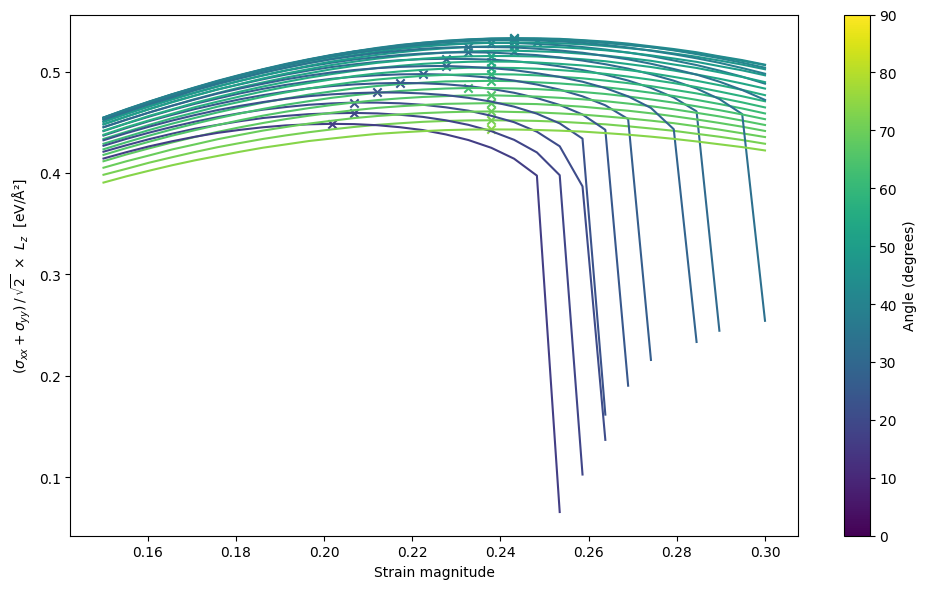

In [15]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# 1. Pre-collect data and angles to determine the scale limits
data_list = []
angles = []

for f in files:
    match = re.match(r'stress_strain_angle(\d+\.\d+)deg\.csv', f)
    if match:
        angle_val = float(match.group(1))
        angles.append(angle_val)
        df = pd.read_csv(os.path.join(DIR, f))
        data_list.append((angle_val, df))

# Extract Lz from the cell_a3z column (vacuum thickness, same for all files)
Lz = data_list[0][1]['cell_a3z'].iloc[0]

# 2. Setup colormap
norm = mcolors.Normalize(vmin=min(angles), vmax=max(angles))
colormap = cm.viridis
scalar_map = cm.ScalarMappable(norm=norm, cmap=colormap)

def metric(sxx, syy, Lz):
    return (sxx + syy) / np.sqrt(2) * Lz

# 3. Plot with colors
plt.figure(figsize=(10, 6))
for angle, df in data_list:
    if angle < 15 or angle > 75:
        continue

    m = metric(df['sxx'], df['syy'], Lz)
    maxi = np.argmax(m)
    maxstrain = df['strain_magnitude'].iloc[maxi]
    maxmetric = m.iloc[maxi]

    plt.plot(df['strain_magnitude'], m, color=scalar_map.to_rgba(angle), label=f'{angle}°')
    plt.scatter(maxstrain, maxmetric, marker='x', color=scalar_map.to_rgba(angle))

# 4. Add colorbar
ax = plt.gca()
cbar = plt.colorbar(scalar_map, ax=ax)
cbar.set_label('Angle (degrees)')

plt.xlabel('Strain magnitude')
plt.ylabel(r'$(\sigma_{xx}+\sigma_{yy})\,/\,\sqrt{2}\ \times\ L_z$  [eV/Å²]')
plt.tight_layout()
plt.show()